In [1]:
words=open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [9]:
b = {}
for w in words:
    char_seq = ['<s>'] + list(w) + ['</s>']

    for ch1, ch2 in zip(char_seq, char_seq[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1

In [16]:
sorted_b=sorted(b.items(), key = lambda k: -k[1])
sorted_b[:4]

[(('n', '</s>'), 6763),
 (('a', '</s>'), 6640),
 (('a', 'n'), 5438),
 (('<s>', 'a'), 4410)]

In [17]:
import torch

In [25]:
N = torch.zeros((28,28), dtype=torch.int32)
chars= sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}
stoi['<s>'] = 26
stoi['</s>'] = 27

In [28]:
b = {}
for w in words:
    char_seq = ['<s>'] + list(w) + ['</s>']

    for ch1, ch2 in zip(char_seq, char_seq[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] +=1

In [31]:
itos = {i:s for s,i in stoi.items()}

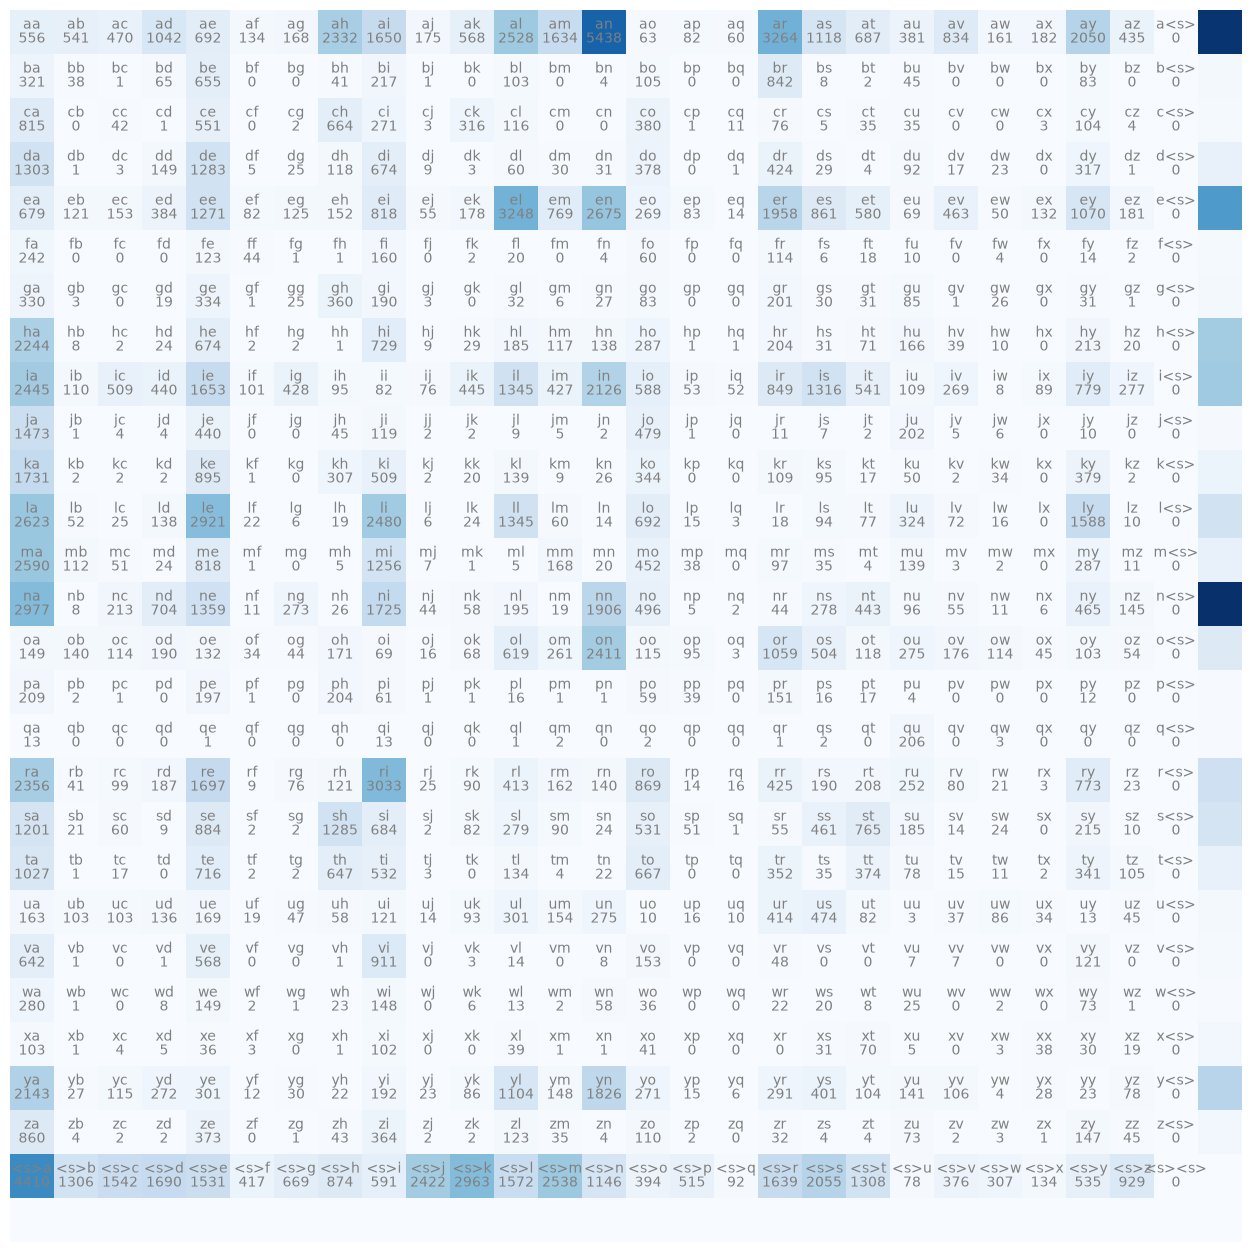

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');